## WorldView Scene-Combination Benchmark: SpaceNet Atlanta

**Given N same-pass scenes, which combinations and which processing flow give the best DEM?** This notebook is the systematic version of the two-DEM comparison in [`worldview_spacenet_atlanta_mvs.ipynb`](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_mvs.html) ([issue #169](https://github.com/uw-cryo/asp_plot/issues/169)). Everything is scored with `asp_plot.dem_benchmark.DEMBenchmark` against **one** ICESat-2 ATL06-SR sample, so every number below is directly comparable.

Three questions, three axes of the experiment:

1. **Convergence angle** — all ten pairs among the five scenes span 5–32°. How does single-pair accuracy depend on it, and where does the pair-selection rule of thumb (20–30°) sit on this data?
2. **Number of scenes** — a nested chain, pair 13-10 ⊂ MVS {13,10,16} ⊂ MVS {13,10,16,21} ⊂ MVS {all five}: does each added scene earn its cost?
3. **Processing flow** — joint multi-view triangulation vs. independent pairs merged with `dem_mosaic`, at three and at five scenes; and whether merging only the well-converged pairs rescues the mosaic.

> **Status.** All 17 DEMs of the matrix are on disk and scored. They were produced by [`run_benchmark.sh`](run_benchmark.sh) next to this notebook (11 h on a laptop; see the *Processing* section). The scoring cells score **whatever DEMs exist on disk** and list the rest as pending, so the notebook stays valid if a run is deleted or a new candidate is added.


---

## Testbed

Five same-pass WorldView-2 scenes over Hartsfield–Jackson Atlanta International Airport (2009-12-22, SpaceNet AOI 6, public on `s3://spacenet-dataset/AOIs/AOI_6_Atlanta/`), all `wv_correct`ed and bundle-adjusted **together** (`ba/run`, five scenes), so every stereo run below shares one camera network and any DEM difference comes from the stereo strategy, not the cameras. See the MVS notebook for the download, `wv_correct`, and `bundle_adjust` steps.

| Name | CATID / tile | Along-track order | Role |
|---|---|---|---|
| nadir10 | `1030010003CAF100_P002` | 1 | |
| nadir8 | `10300100023BC100_P001` | 2 | |
| nadir13 | `1030010002B7D800_P002` | 3 | reference scene of every MVS run (crop window `5879 13107 12981 11894`) |
| nadir16 | `1030010002649200_P001` | 4 | |
| nadir21 | `1030010003127500_P001` | 5 | |

`bundle_adjust` reports the convergence angle of every image pair that had matches, which is the first axis of the experiment:

In [1]:
import os

import numpy as np
import pandas as pd

# Set the base directory for your processing
directory = "~/Desktop/asp-plot-examples/atlanta_mvs/"
directory = os.path.expanduser(directory)

SCENES = {
    "1030010003CAF100_P002": "10",
    "10300100023BC100_P001": "8",
    "1030010002B7D800_P002": "13",
    "1030010002649200_P001": "16",
    "1030010003127500_P001": "21",
}

# ba/run-convergence_angles.txt: left right 25% 50% 75% num_matches (degrees)
conv = pd.read_csv(
    f"{directory}ba/run-convergence_angles.txt",
    sep=r"\s+",
    comment="#",
    names=["left", "right", "p25", "p50", "p75", "num_matches"],
)
for col in ("left", "right"):
    conv[col] = conv[col].str.replace("_corr.tif", "", regex=False).map(SCENES)


def pair_dir(a, b):
    """stereo_pair_<A>_<B> as produced by run_pairwise.sh / run_benchmark.sh (either order)."""
    for left, right in ((a, b), (b, a)):
        d = f"stereo_pair_{left}_{right}"
        if os.path.isdir(f"{directory}{d}"):
            return d
    return f"stereo_pair_{a}_{b}"


conv["pair"] = conv.apply(lambda r: f"{r.left}-{r.right}", axis=1)
conv["run_dir"] = conv.apply(lambda r: pair_dir(r.left, r.right), axis=1)
conv["dem_exists"] = conv["run_dir"].map(lambda d: os.path.exists(f"{directory}{d}/run-DEM.tif"))
conv = conv.sort_values("p50").reset_index(drop=True)
conv[["pair", "p50", "p25", "p75", "num_matches", "run_dir", "dem_exists"]].rename(
    columns={"p50": "convergence (deg)"}
)

,pair,convergence (deg),p25,p75,num_matches,run_dir,dem_exists
0,13-16,5.123524,4.831792,5.479853,7451,stereo_pair_13_16,True
1,16-21,5.361678,5.327280,5.394798,6201,stereo_pair_16_21,True
2,8-10,5.456345,5.099122,5.876843,7305,stereo_pair_10_8,True
3,13-21,10.507380,10.241351,10.817621,4813,stereo_pair_13_21,True
4,13-8,16.325202,15.900078,16.673266,5550,stereo_pair_13_8,True
5,8-16,21.465489,21.401535,21.518222,3707,stereo_pair_8_16,True
6,13-10,21.791530,21.786859,21.795557,4725,stereo_pair_13_10,True
7,8-21,26.834443,26.725781,26.920276,2188,stereo_pair_8_21,True
8,10-16,26.934903,26.626338,27.294847,2822,stereo_pair_10_16,True
9,10-21,32.293319,32.017714,32.622930,1860,stereo_pair_10_21,True


Ten pairs, evenly spread from 5° to 32°, with three of them already run for the MVS example (5.1°, 21.8°, 26.9°). The match count falls with convergence, as expected for the same interest-point detector seeing an increasingly different view.

### Crop windows for the new pairs

Every existing run crops the reference scene (nadir13) to the airport window and lets ASP find the corresponding region in the other image. A pair whose *left* image is not nadir13 needs its own `--left-image-crop-win`, which is derived the same way `run_pairwise.sh` derived nadir10's: take the `bundle_adjust` clean match points between nadir13 and that scene, keep those inside the nadir13 crop, and pad the bounding box of their partners by 100 px. nadir10's window reproduces the one used for `stereo_pair_10_16`, which validates the method; the other three are what `run_benchmark.sh` uses.

In [2]:
from asp_plot.stereo import StereoPlotter

XOFF, YOFF, W, H = 5879, 13107, 12981, 11894  # nadir13 reference crop
REF = "1030010002B7D800_P002"

stereo_plotter = StereoPlotter(directory, "stereo_mvs3")
crops = {"13": (XOFF, YOFF, W, H)}
for cid, name in SCENES.items():
    if cid == REF:
        continue
    match_fn = f"{directory}ba/run-{REF}_corr__{cid}_corr-clean.match"
    match_df = stereo_plotter.get_match_point_df(match_point_fn=match_fn)
    inwin = match_df[match_df.x1.between(XOFF, XOFF + W) & match_df.y1.between(YOFF, YOFF + H)]
    pad = 100
    x0, y0 = int(inwin.x2.min()) - pad, int(inwin.y2.min()) - pad
    x1, y1 = int(inwin.x2.max()) + pad, int(inwin.y2.max()) + pad
    crops[name] = (x0, y0, x1 - x0, y1 - y0)
    print(
        f"nadir{name:<3} {len(inwin):5d} of {len(match_df):5d} clean matches in the reference crop"
        f"  -> --left-image-crop-win {x0} {y0} {x1 - x0} {y1 - y0}"
    )


No reference DEM found in log files. Please supply the reference DEM you used during stereo processing (or another reference DEM) if you would like to see some difference maps.





ASP DEM: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_mvs3/run-DEM.tif

nadir10    775 of  4725 clean matches in the reference crop  -> --left-image-crop-win 5540 13223 13206 12931
nadir8     890 of  5550 clean matches in the reference crop  -> --left-image-crop-win 5461 9789 13354 12980
nadir16   1176 of  7451 clean matches in the reference crop  -> --left-image-crop-win 6083 8756 12879 11461
nadir21    785 of  4813 clean matches in the reference crop  -> --left-image-crop-win 6467 8177 12495 10687


---

## Processing

[`run_benchmark.sh`](run_benchmark.sh) runs everything the matrix needs that the MVS example did not, with the settings of the existing runs (`asp_mgm`, `--subpixel-mode 9`, `affineepipolar`, the shared `ba/run` prefix, `point2dem --tr 1.9 --t_srs EPSG:32616 --errorimage`). Every step is skipped when its product exists, so it can be re-run after an interruption:

```bash
$ bash notebooks/WorldView/run_benchmark.sh ~/Desktop/asp-plot-examples/atlanta_mvs
```

| Step | Products | Answers |
|---|---|---|
| `wv_correct` × 5 | `<catid>_corr.tif` | (the intermediates were purged after the earlier runs) |
| the seven remaining pairs | `stereo_pair_13_8`, `_13_21`, `_10_8`, `_10_21`, `_8_16`, `_8_21`, `_16_21` | axis 1: NMAD vs. convergence over all ten pairs |
| `dem_mosaic` of all ten pairs / of the six pairs > 15° | `pairwise10_mosaic-DEM.tif`, `pairwise_wide6_mosaic-DEM.tif` | axis 3: the five-scene pairwise flows |
| nested quad `{13,10,16,21}` | `stereo_mvs4/` | axis 2: the 2→3→4→5 chain |
| wide-spread triple `{13,8,21}` | `stereo_mvs3_wide/` | axis 2/3: does the *choice* of three scenes matter as much as their number? |
| the five scenes referenced on **nadir10** | `stereo_mvs5_ref10/` | axis 2/3: ASP matches every scene to the reference only, so a multi-view run is a star of reference-to-scene pairs — nadir13's is 16.3/21.8/5.1/10.5°, nadir10's 5.5/21.8/26.9/32.3°. Same scenes, same cameras, only the star changes |
| `dem_mosaic --median` and a convergence-weighted `dem_mosaic` of all ten pairs | `pairwise10_median_mosaic-DEM.tif`, `pairwise10_convw_mosaic-DEM.tif` | axis 3: can a smarter blend replace pair selection? |
| ASP's documented recipe: every pair re-triangulated with `--propagate-errors`, `point2dem --propagate-errors`, `dem_mosaic --weight-list <VerticalStdDev> --invert-weights` | `stereo_pair_*_err/`, `pairwise10_vstd_mosaic-DEM.tif` | axis 3: the *sfm_multiview* flow exactly as the ASP manual describes it |

Measured on an 8-thread laptop (2026-08-31, steps 1–3): 11 h 03 min end to end — 52–74 min per pair (62 min average), 1 h 27 min for the triple, 2 h 18 min for the quad, and 7–10 s per `dem_mosaic`. Disk is the real cost: ~100 GB (7–8 GB per pair, 12 GB for the triple, 18 GB for the quad), almost all of it the `F`/`RD`/`R` correlation intermediates, which can be deleted once the DEMs are scored.

Steps 4–6 were added afterwards (2026-09-10): the nadir10-referenced run took 3 h 54 min; re-triangulating a pair through `stereo_tri` on its existing `run-F.tif` takes ~16 min, and the three July pairs whose correlation intermediates had been cleaned up were re-run in full (~1 h each). `parallel_stereo --prev-run-prefix` cannot do the re-triangulation on a finished run — it looks for the per-tile `F.tif` files that the default `--keep-only all_combined` deletes — which is why the script calls `stereo_tri` directly.


---

## Scoring every DEM against one ICESat-2 sample

`DEMBenchmark` scores each candidate with the report's recipe — the cached ATL06-SR parquet replayed (no SlideRule request), ESA WorldCover water returns dropped, a 3σ outlier cut per DEM — and a `pc_align --compute-translation-only` of its own, whose products go under `dem_benchmark/<label>/`. Coverage and triangulation error are measured inside the **common footprint** of all the DEMs scored. The candidate list below is the full matrix; DEMs that have not been produced yet are reported as pending and the rest are scored.

In [3]:
from asp_plot.dem_benchmark import DEMBenchmark

conv_of = dict(zip(conv["pair"], conv["p50"]))

candidates = {}
for _, r in conv.iterrows():
    candidates[f"pair {r.pair} ({r.p50:.1f}°)"] = f"{directory}{r.run_dir}/run-DEM.tif"
candidates.update(
    {
        "3 pairs + mosaic {13,10,16}": f"{directory}pairwise_mosaic-DEM.tif",
        "6 pairs > 15° + mosaic": f"{directory}pairwise_wide6_mosaic-DEM.tif",
        "10 pairs + mosaic": f"{directory}pairwise10_mosaic-DEM.tif",
        "10 pairs + median mosaic": f"{directory}pairwise10_median_mosaic-DEM.tif",
        "10 pairs + conv-weighted mosaic": f"{directory}pairwise10_convw_mosaic-DEM.tif",
        "MVS 3 {13,10,16}": f"{directory}stereo_mvs3/run-DEM.tif",
        "MVS 3 {13,8,21}": f"{directory}stereo_mvs3_wide/run-DEM.tif",
        "MVS 4 {13,10,16,21}": f"{directory}stereo_mvs4/run-DEM.tif",
        "MVS 5": f"{directory}stereo_mvs5/run-DEM.tif",
        "MVS 5 ref nadir10": f"{directory}stereo_mvs5_ref10/run-DEM.tif",
    }
)

existing = {k: v for k, v in candidates.items() if os.path.exists(v)}
pending = [k for k in candidates if k not in existing]
print(f"{len(existing)} of {len(candidates)} candidates on disk; pending: {pending}\n")

bench = DEMBenchmark(
    directory=directory,
    dems=existing,
    parquet=f"{directory}atl06sr_all.parquet",
    reference="MVS 5",
    title="Atlanta WV2 2009-12-22: same-pass scene combinations",
)
stats = bench.run()
stats.drop(columns=["dem_fn", "gsd_m", "north_shift_m", "east_shift_m", "down_shift_m"]).round(2)

17 of 17 candidates on disk; pending: []


=== [1/17] pair 13-16 (5.1°): /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_pair_13_16/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/atl06sr_all.parquet


Filtering ATL06-SR all


  Outlier filter (3σ): all 7937 → 7779 (removed 158)
  7013 altimetry points: median +0.49 m, NMAD 1.54 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/pair_13-16_5.1/pc_align



Writing out: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/pair_13-16_5.1/run-DEM_pc_align_translated.tif



...


=== [17/17] MVS 5: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/stereo_mvs5/run-DEM.tif


Reusing ICESat-2 ATL06-SR points for 'all' from: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/atl06sr_all.parquet
Filtering ATL06-SR all


  Outlier filter (3σ): all 7937 → 7756 (removed 181)
  7043 altimetry points: median +0.12 m, NMAD 0.68 m
  Reusing pc_align output in /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/MVS_5/pc_align

Writing out: /Users/ben/Desktop/asp-plot-examples/atlanta_mvs/dem_benchmark/MVS_5/run-DEM_pc_align_translated.tif



  after pc_align (|t| = 0.60 m): median +0.19 m, NMAD 0.68 m


,label,valid_pct,valid_area_km2,ie_median_m,ie_nmad_m,n_points,dh_median_m,dh_nmad_m,dh_rmse_m,translation_m,dh_aligned_median_m,dh_aligned_nmad_m,dh_aligned_rmse_m,vs_ref_median_m,vs_ref_nmad_m
0,pair 13-16 (5.1°),95.51,36.28,0.07,0.06,7013,0.49,1.54,2.63,0.63,0.27,1.54,2.61,-0.27,1.06
1,pair 16-21 (5.4°),98.23,37.32,0.07,0.06,7300,-1.46,1.54,3.02,1.69,-0.17,1.53,2.59,1.62,1.05
2,pair 8-10 (5.5°),97.25,36.94,0.07,0.06,7230,0.83,1.64,2.80,0.95,0.11,1.65,2.72,-0.59,1.15
3,pair 13-21 (10.5°),96.69,36.73,0.10,0.08,7058,-0.33,1.06,2.37,0.78,0.15,1.06,2.35,0.49,0.56
4,pair 13-8 (16.3°),95.68,36.35,0.10,0.08,7015,0.01,0.86,2.33,0.62,0.24,0.85,2.33,0.09,0.43
5,pair 8-16 (21.5°),95.97,36.46,0.08,0.07,7051,0.20,0.73,2.29,0.61,0.18,0.73,2.30,-0.11,0.34
6,pair 13-10 (21.8°),95.58,36.31,0.11,0.09,6947,0.29,0.71,2.32,0.61,0.17,0.72,2.35,-0.20,0.28
7,pair 8-21 (26.8°),95.14,36.14,0.07,0.06,6937,-0.09,0.65,2.20,0.64,0.17,0.65,2.22,0.18,0.28
8,pair 10-16 (26.9°),95.00,36.09,0.08,0.07,6940,0.40,0.64,2.23,0.63,0.16,0.64,2.19,-0.29,0.28
9,pair 10-21 (32.3°),94.40,35.86,0.09,0.08,6896,0.12,0.62,2.23,0.98,0.21,0.62,2.23,-0.02,0.29


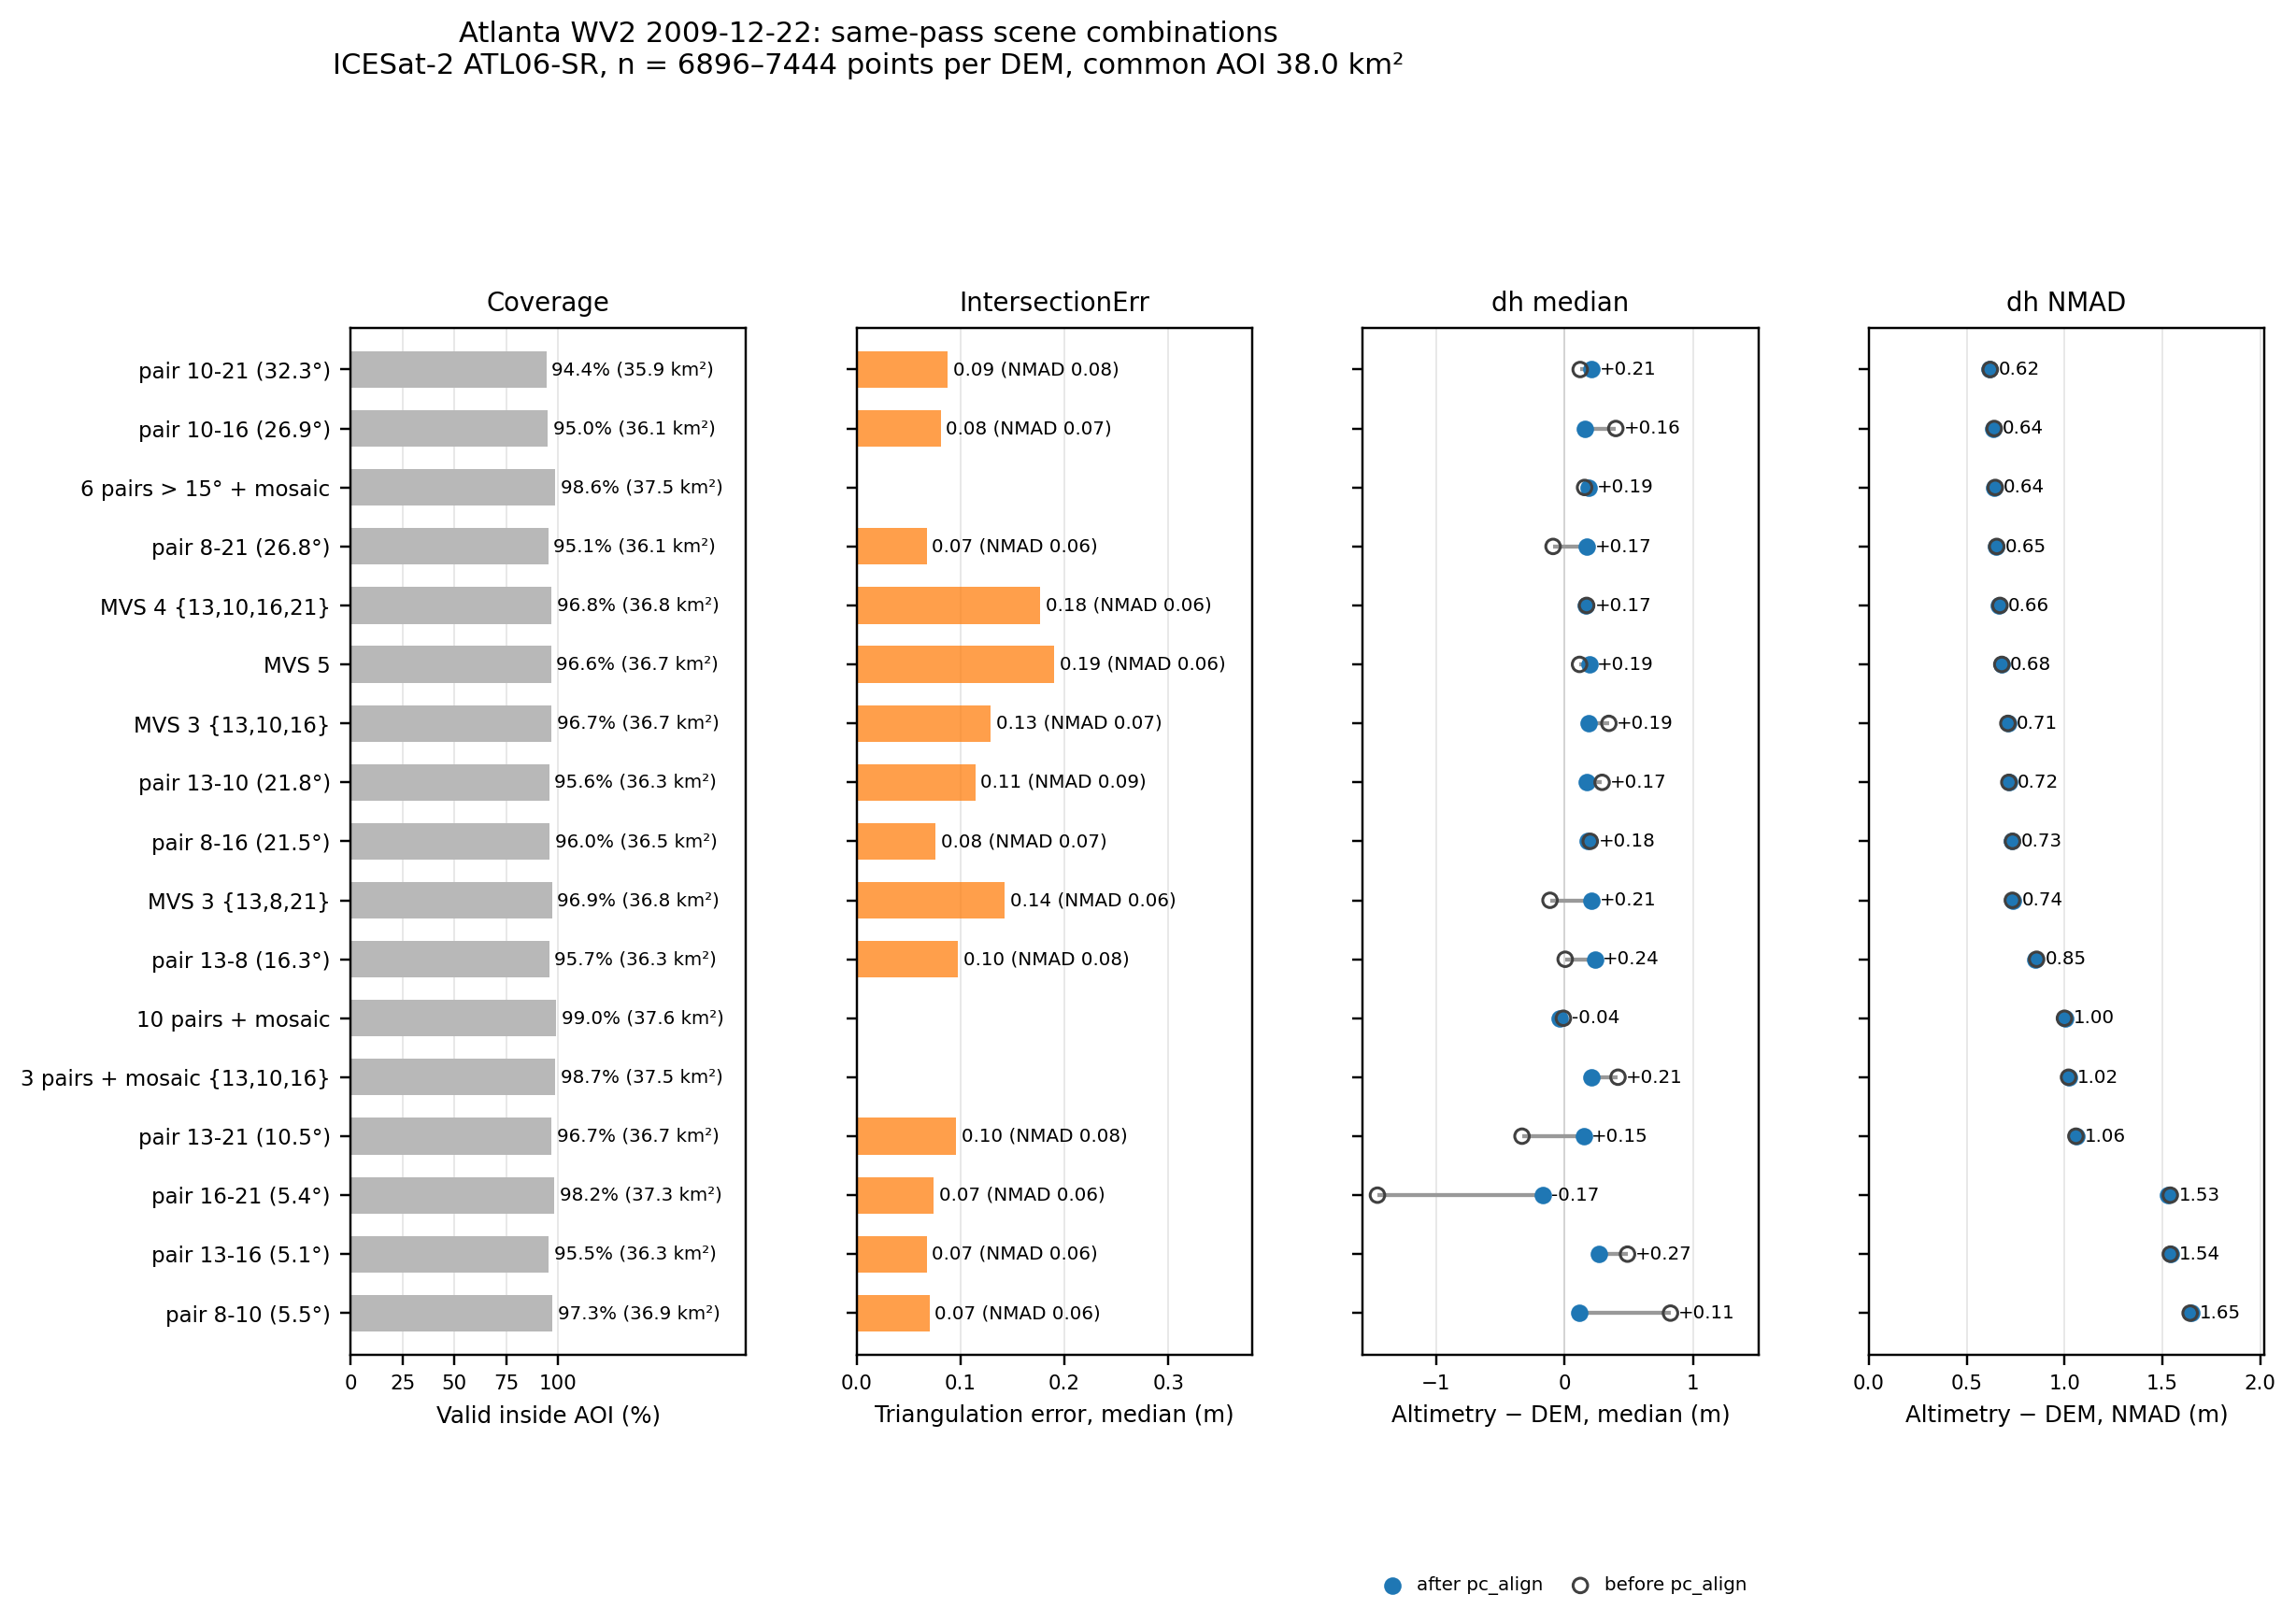

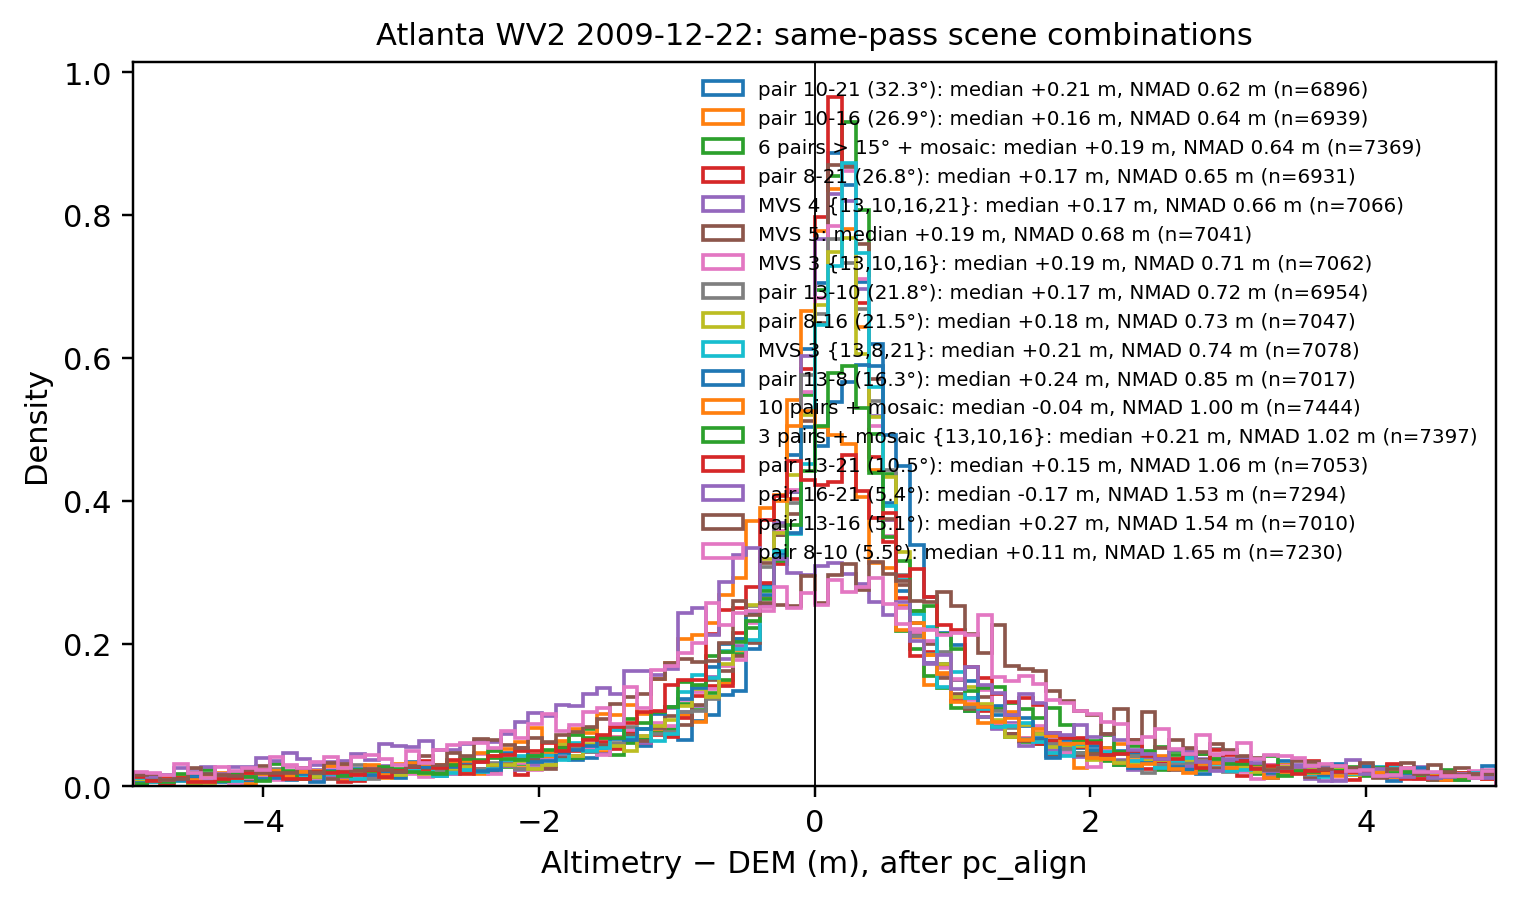

In [4]:
_ = bench.summary_plot()
_ = bench.histogram_plot()

---

## Axis 1 — single-pair accuracy vs. convergence angle

Each point is one pair, scored after its own `pc_align` translation (the translation removes bias and cannot change NMAD, so NMAD is the fair single-pair number). The 20–30° rule of thumb used in the scene-selection notebook is shaded.

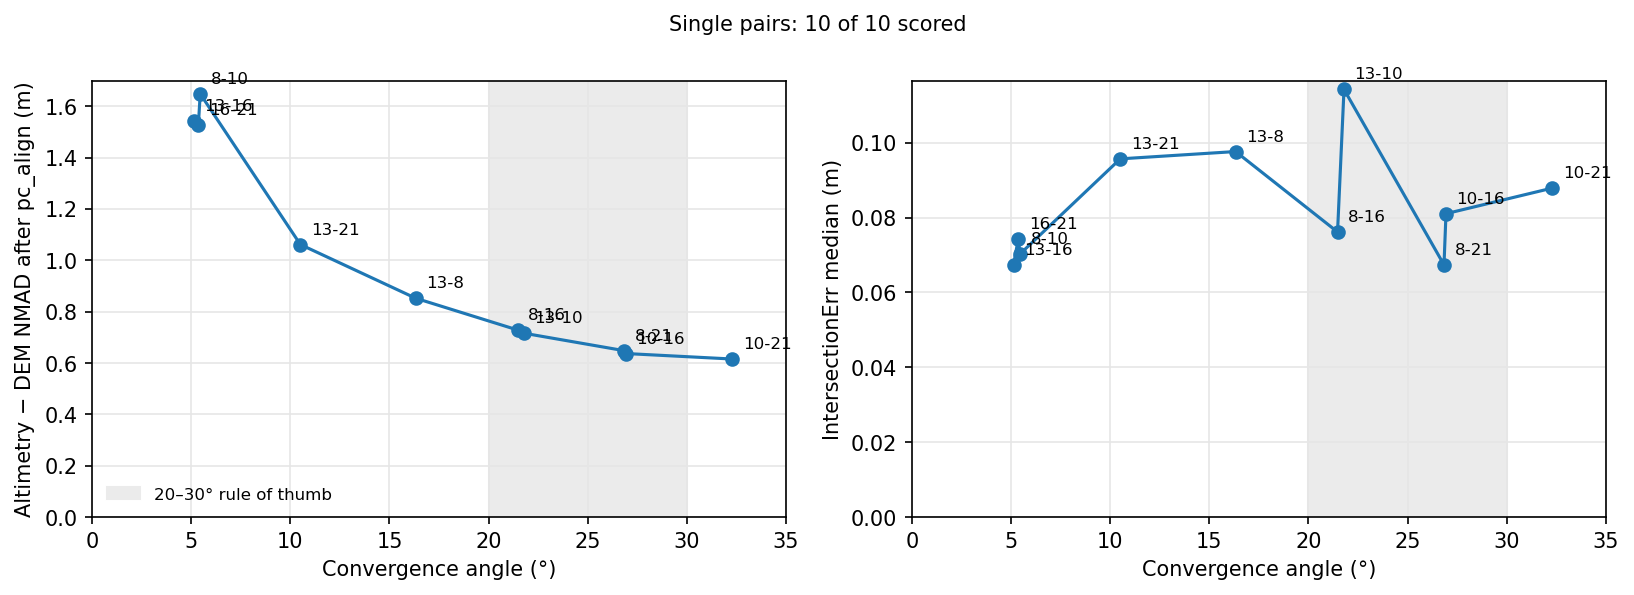

In [5]:
import matplotlib.pyplot as plt

by = stats.set_index("label")
pairs = by[by.index.str.startswith("pair ")].copy()
pairs["convergence"] = [conv_of[lbl.split()[1]] for lbl in pairs.index]
pairs = pairs.sort_values("convergence")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), dpi=150)
for ax, col, ylabel in (
    (axes[0], "dh_aligned_nmad_m", "Altimetry − DEM NMAD after pc_align (m)"),
    (axes[1], "ie_median_m", "IntersectionErr median (m)"),
):
    ax.axvspan(20, 30, color="0.92", zorder=0, label="20–30° rule of thumb")
    ax.plot(pairs["convergence"], pairs[col], "o-", color="tab:blue")
    for c, v, lbl in zip(pairs["convergence"], pairs[col], pairs.index):
        ax.annotate(lbl.split()[1], (c, v), textcoords="offset points", xytext=(5, 5), fontsize=8)
    ax.set_xlabel("Convergence angle (°)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, 35)
    ax.set_ylim(bottom=0)
    ax.grid(color="0.9")
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle(f"Single pairs: {len(pairs)} of 10 scored" + (" (rest pending)" if len(pairs) < 10 else ""), fontsize=10)
fig.tight_layout()

---

## Axis 2 — does each added scene earn its cost?

A nested chain, so each step adds exactly one scene to the previous run: pair 13-10 (21.8°) → MVS {13,10,16} → MVS {13,10,16,21} → MVS {13,10,16,21,8}. The wide-spread triple {13,8,21} is plotted alongside as a check that *which* three scenes matters, not only how many.

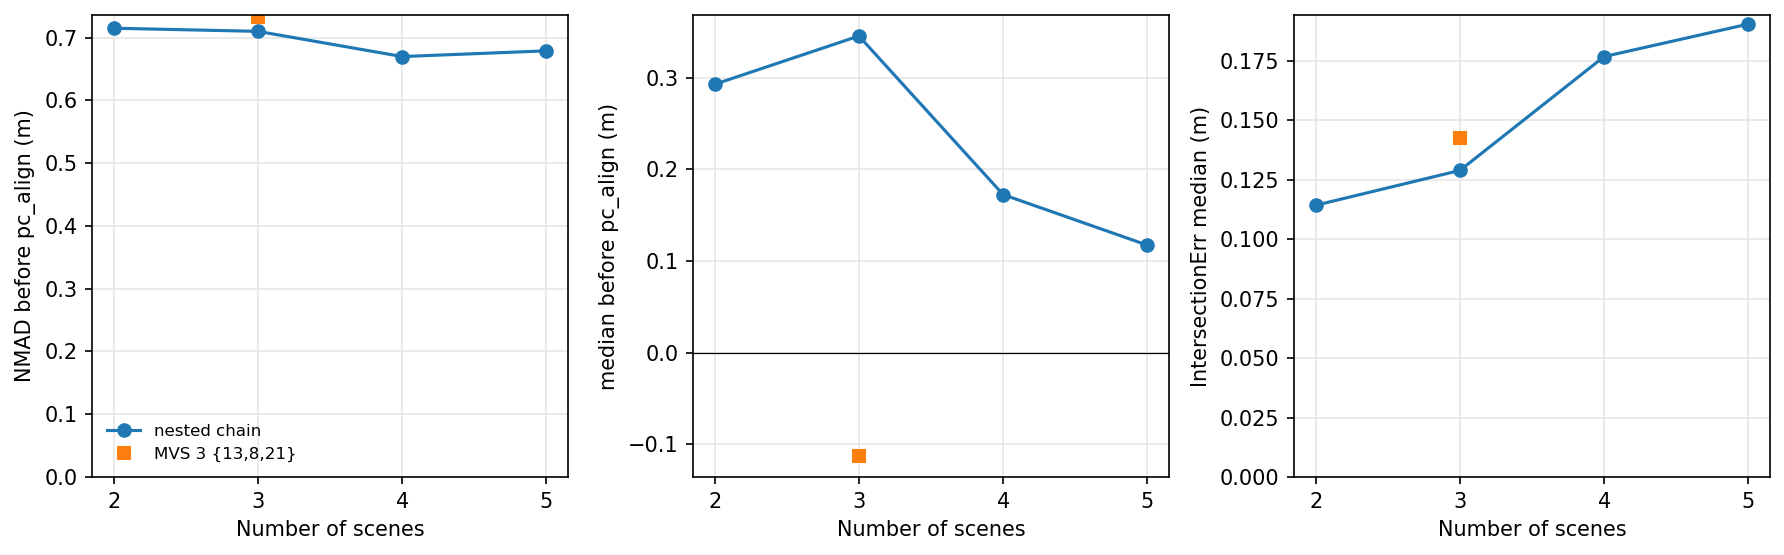

In [6]:
chain = [
    ("pair 13-10 (21.8°)", 2),
    ("MVS 3 {13,10,16}", 3),
    ("MVS 4 {13,10,16,21}", 4),
    ("MVS 5", 5),
]
present = [(lbl, n) for lbl, n in chain if lbl in by.index]
missing = [lbl for lbl, _ in chain if lbl not in by.index]
if missing:
    print("pending:", missing)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=150)
for ax, col, ylabel in (
    (axes[0], "dh_nmad_m", "NMAD before pc_align (m)"),
    (axes[1], "dh_median_m", "median before pc_align (m)"),
    (axes[2], "ie_median_m", "IntersectionErr median (m)"),
):
    ax.plot([n for _, n in present], [by.loc[lbl, col] for lbl, _ in present], "o-", color="tab:blue", label="nested chain")
    if "MVS 3 {13,8,21}" in by.index:
        ax.plot([3], [by.loc["MVS 3 {13,8,21}", col]], "s", color="tab:orange", label="MVS 3 {13,8,21}")
    if "MVS 5 ref nadir10" in by.index:
        ax.plot([5], [by.loc["MVS 5 ref nadir10", col]], "D", color="tab:green", label="MVS 5 ref nadir10")
    ax.set_xticks([2, 3, 4, 5])
    ax.set_xlabel("Number of scenes")
    ax.set_ylabel(ylabel)
    ax.grid(color="0.9")
    if col == "dh_median_m":
        ax.axhline(0, color="k", lw=0.6)
    else:
        ax.set_ylim(bottom=0)  # spreads and errors are anchored at zero, as in summary_plot
axes[0].legend(fontsize=8, frameon=False)
fig.tight_layout()

---

## Axis 3 — joint triangulation vs. pairwise + mosaic

The same scenes processed two ways. The five-scene pairwise flow is shown in five variants of the blend — every pair with `dem_mosaic`'s default weighted average, only the six pairs above 15°, the median of all ten, all ten weighted by convergence angle, and all ten weighted by the propagated vertical uncertainty exactly as the ASP manual's *Multiview reconstruction* section prescribes — against the joint triangulation with nadir13 and with nadir10 as reference. The variants ask whether the mosaic's problem is *averaging*, or *averaging bad pairs in*, and whether a smarter blend can replace choosing the pairs by hand.


In [7]:
flows = [
    ("3 scenes", "MVS 3 {13,10,16}", "3 pairs + mosaic {13,10,16}"),
    ("5 scenes", "MVS 5", "10 pairs + mosaic"),
    ("5 scenes, > 15° only", "MVS 5", "6 pairs > 15° + mosaic"),
    ("5 scenes, median blend", "MVS 5", "10 pairs + median mosaic"),
    ("5 scenes, conv-weighted blend", "MVS 5", "10 pairs + conv-weighted mosaic"),
    ("5 scenes, reference nadir10", "MVS 5 ref nadir10", "6 pairs > 15° + mosaic"),
]
cols = ["valid_pct", "ie_median_m", "n_points", "dh_median_m", "dh_nmad_m", "dh_aligned_median_m", "dh_aligned_nmad_m"]
rows = []
for scenes, mvs, mosaic in flows:
    for flow, lbl in (("MVS", mvs), ("pairwise + mosaic", mosaic)):
        if lbl in by.index:
            rows.append({"scenes": scenes, "flow": flow, "DEM": lbl} | by.loc[lbl, cols].to_dict())
        else:
            rows.append({"scenes": scenes, "flow": flow, "DEM": f"{lbl} (pending)"})
pd.DataFrame(rows).set_index(["scenes", "flow"]).round(2)

DEM  \
scenes               flow                                             
3 scenes             MVS                           MVS 3 {13,10,16}   
                     pairwise + mosaic  3 pairs + mosaic {13,10,16}   
5 scenes             MVS                                      MVS 5   
                     pairwise + mosaic            10 pairs + mosaic   
5 scenes, > 15° only MVS                                      MVS 5   
                     pairwise + mosaic       6 pairs > 15° + mosaic   

                                        valid_pct  ie_median_m  n_points  \
scenes               flow                                                  
3 scenes             MVS                    96.71         0.13    7064.0   
                     pairwise + mosaic      98.71          NaN    7393.0   
5 scenes             MVS                    96.61         0.19    7043.0   
                     pairwise + mosaic      99.03          NaN    7444.0   
5 scenes, > 15° only MVS                    96.61         0.19    7043.0   
                     pairwise + mosaic      98.59          NaN    7368.0   

                                        dh_median_m  dh_nmad_m  \
scenes               flow                                        
3 scenes             MVS                       0.35       0.71   
                     pairwise + mosaic         0.42       1.02   
5 scenes             MVS                       0.12       0.68   
                     pairwise + mosaic        -0.01       1.00   
5 scenes, > 15° only MVS                       0.12       0.68   
                     pairwise + mosaic         0.16       0.65   

                                        dh_aligned_median_m  dh_aligned_nmad_m  
scenes               flow                                                       
3 scenes             MVS                               0.19               0.71  
                     pairwise + mosaic                 0.21               1.02  
5 scenes             MVS                               0.19               0.68  
                     pairwise + mosaic                -0.04               1.00  
5 scenes, > 15° only MVS                               0.19               0.68  
                     pairwise + mosaic                 0.19               0.64

---

## Takeaways

Seventeen DEMs from the same five scenes, the same cameras and the same ICESat-2 sample. After `pc_align` every median lands at +0.15 to +0.27 m (the two exceptions, the 10-pair mosaic at −0.04 m and pair 16-21 at −0.17 m, are within the noise of a translation fit), and no NMAD moves — so the ranking that survives alignment is the NMAD one, and that is the number quoted below.

**Axis 1 — convergence angle is the whole story for a single pair.** NMAD falls monotonically from 1.5–1.65 m at 5° to 1.06 m at 10.5°, 0.85 m at 16°, 0.72–0.73 m at 21–22°, 0.64–0.65 m at 27° and 0.62 m at 32°, with no sign of matching degrading at the wide end. The 20–30° rule of thumb is where the curve flattens: the last ten degrees buy 0.1 m, the first ten cost 0.9 m. IntersectionErr says none of this — it sits at 0.07–0.11 m for every pair, *lowest* for the three worst DEMs — because a narrow pair's rays intersect precisely at the wrong height.

**Axis 2 — more scenes do not mean a better DEM.** The nested chain pair 13-10 → MVS 3 → MVS 4 → MVS 5 goes 0.72 → 0.71 → 0.66 → 0.68 m: adding nadir16 and nadir8 to the joint triangulation changes nothing, adding nadir21 gains 0.05 m. What the extra scenes do buy is bias — the pre-alignment median shrinks from +0.29 m to +0.12 m — and a growing IntersectionErr (0.11 → 0.19 m), which is a count of rays, not a measure of quality. The wide-spread triple {13,8,21} (0.74 m) is no better than the close one {13,10,16} (0.71 m).

The reason is how ASP's multi-view stereo is built: **every scene is matched to the reference image, never to each other.** `stereo_mvs5/run-pair1..4/` are nadir13 with nadir8, nadir10, nadir16 and nadir21 — convergence 16.3°, 21.8°, 5.1° and 10.5° — and the joint triangulation intersects those four rays per reference pixel. Only one of them clears 20°. The best geometry in the data set — 10-21 at 32.3°, 10-16 at 26.9°, 8-21 at 26.8° — never enters an MVS run here, because none of those pairs contains the reference. MVS 5 at 0.68 m is what the *nadir13 star* can do, not what five scenes can do; a run referenced on nadir10 would be built from 5.5°, 21.8°, 26.9° and 32.3° pairs and is the obvious next experiment.

**Axis 3 — pairwise + mosaic beats joint triangulation *if, and only if, you choose the pairs*.** Merging every pair loses to MVS at three scenes (1.02 vs. 0.71 m) and at five (1.00 vs. 0.68 m): `dem_mosaic`'s weighted average lets a 1.5 m pair pull two 0.65 m pairs down to 1.0 m. Merging only the six pairs above 15° gives **0.64 m — the best DEM of the seventeen after the two widest pairs**, with the highest coverage of any non-trivial flow (98.6 %, the mosaic fills each pair's holes with another's), a small pre-alignment bias (+0.16 m), and a 0.25 m NMAD against MVS 5 pixel for pixel. So the mosaic's problem was never averaging; it was averaging weak pairs in — and the pairwise flow can drop them, while the multi-view flow is locked to whatever the reference star contains.

**What this means for "MVS performs worse".** On this data set it is neither true nor false as stated. Joint triangulation is the more robust default — it cannot be ruined by a bad pair the way an unfiltered mosaic can, and it has the lowest bias — but it is capped by the reference geometry, and a curated pairwise mosaic edges past it. Both flows are limited by the same thing, convergence angle; they differ in whether you are allowed to exclude the narrow pairs.

**Caveats.** One site (flat, urban, same-pass WorldView-2), one 38 km² footprint, a 1.9 m grid, and one altimetry sample. The `dem_mosaic` runs use the default weighted blend; `--median` or a convergence-weighted blend might do better still. A multi-view run referenced on nadir10, and ASP's own `multi_stereo --mode dem_mosaic` (not in the 3.8.0-alpha build used here), are the two candidates the matrix is missing.

An independent check exists: in [issue #156](https://github.com/uw-cryo/asp_plot/issues/156) the MVS 5 and 3-pair mosaic DEMs were also assessed against NGS survey monuments and FAA runway ends via `groundcontrol`, which ranked them the same way.
